In [13]:
%load_ext autoreload
%autoreload 2

# Importing the modules

import config_dict as cfg                    # config = physical & simulation parameters 
from solver_2DHcurl_1DH1 import *            # solver = mesh build, physics import and FEM method + pmls initialization
import PP_Run_and_Save as pp_run     # post process run and save = run scan function and save data in H5 files
import PP_Plot_and_Load as pp_plot   # post process load and plot = recover the sim data from H5 files and plot graphs "instantly"

from pathlib import Path

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
mode = "RADIAL_ONLY" # "RADIAL_ONLY" or "FULL-2D"
solver = LHCouplingSolver_2DHcurl_1DH1(cfg.__dict__, mode)

In [15]:
mesh_save_dir = Path("/home/remi/Perso/Stage/M2_IRFM/Codes/2D_Complete_Version/Meshes")
# mesh_save_dir = Path("/Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/Meshes")
mesh_save_dir.mkdir(parents=True, exist_ok=True)

figure_save_dir = Path("/home/remi/Perso/Stage/M2_IRFM/Codes/2D_Complete_Version/Figures")
# figure_save_dir = Path("/Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/Figures")
figure_save_dir.mkdir(parents=True, exist_ok=True)


solver.build_physics_Stix_B_field()
mesh = solver.build_mesh_with_PMLs()
# print('num_vertices = ', mesh.nv)

GF_E_field, _ = solver.solve_helmholtz_2DHcurl_1DH1_with_pml(mesh)

Lz_plasma = 4.05e-02m, Lz_pml = 4.00e-02m
lambda_para = 4.05e-02m

[MESH BUILDER - RADIAL_ONLY] :
  --> SW n_perp_p : 8.98203e+00+0.00000e+00j, n_perp_m = 0.00000e+00+1.62548e+00j
  --> Effective meshing index used : 8.98203e+00
  --> h_max resolution : 1.12760e-03 m
#DoFs = 34544 (= number of mesh points).
--- Solving the 3D vector linear system ---
  --> Success | Gamma_Radial: 5.92e-02 | Gamma_Toroidal: 2.28e-02


In [16]:
# Create the Run_XXX_XXX file in Simulation_Results folder
# run_folder = /Simulation_Results/Run_XXX
run_folder_path = pp_run.setup_output_directory("Simulation_Results", save_data=True)

# Total Run_XXX folder path to Remi's shared zone (cea intra) 
run_folder_tot_path = "/home/remi/Perso/Stage/M2_IRFM/Codes/2D_Complete_Version/" + run_folder_path
# run_folder_tot_path = '/Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/' + run_folder_path
print(f'sim_target_folder: {run_folder_tot_path}')



[SYSTEM] Output directory created: Simulation_Results/Run_20260529_074841
sim_target_folder: /home/remi/Perso/Stage/M2_IRFM/Codes/2D_Complete_Version/Simulation_Results/Run_20260529_074841


In [17]:
E_map2D_h5_filepath = pp_run.run_2D_wave_map(mesh, GF_E_field, cfg, run_folder_tot_path, mode)


--- Extracting 2D Wave Map ---
params recover in run_2D_wave_map
Params recovered
h5_path = /home/remi/Perso/Stage/M2_IRFM/Codes/2D_Complete_Version/Simulation_Results/Run_20260529_074841/Wave_Map_2D.h5
type(h5_path) = <class 'str'>
oui
--- 2D Map saved to /home/remi/Perso/Stage/M2_IRFM/Codes/2D_Complete_Version/Simulation_Results/Run_20260529_074841/Wave_Map_2D.h5 ---


--- Plotting 2D Map from /home/remi/Perso/Stage/M2_IRFM/Codes/2D_Complete_Version/Simulation_Results/Run_20260529_074841/Wave_Map_2D.h5 ---


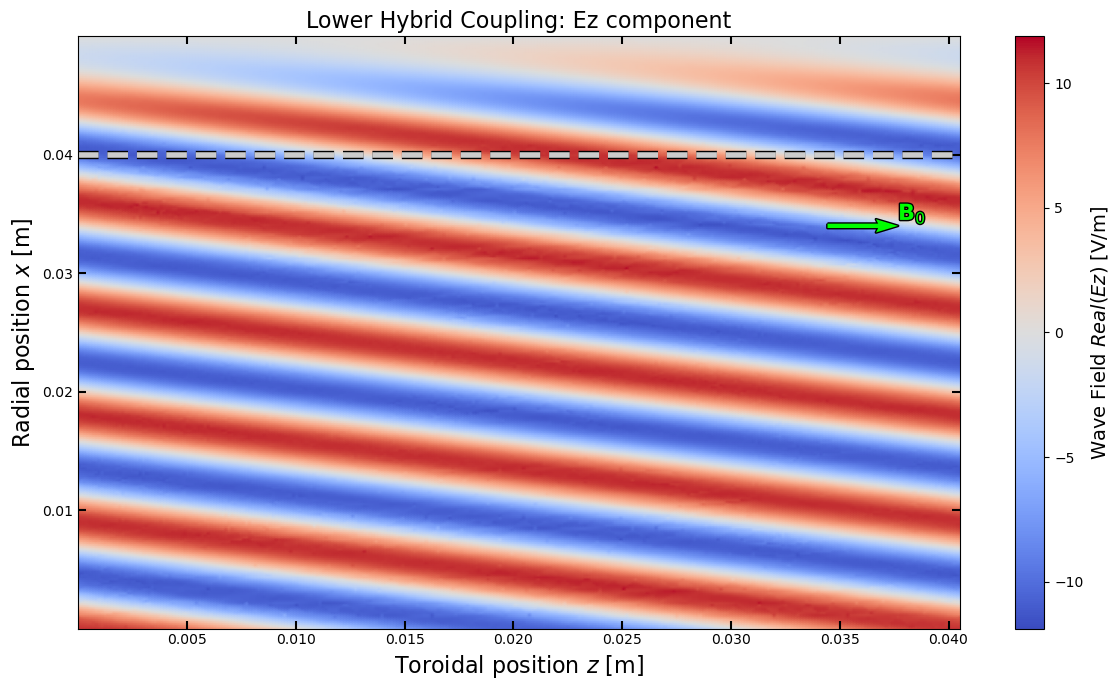

In [18]:
# --- Post-treatment: --- 
# Generate the H5 file for 2D map plot and save it in Run_XXX folder 

import PP_Plot_and_Load as new_pp_plot
# Plot E field 2D map and save it in the same folder: Run_XXX 
new_pp_plot.plot_2D_wave_map(E_map2D_h5_filepath, run_folder_tot_path, mode, component='Ez', value_type='real', plot_e_vectors=False)

In [19]:
# --- TEST PML PARAMS SENSIBILITY ---
# Sx_r, Sx_Im, px, Lx_pml_ratio (in lmin(ambda_perp)), ne, B, 

mode = "RADIAL_ONLY" # "RADIAL_ONLY" or "FULL-2D"
solver = LHCouplingSolver_2DHcurl_1DH1(cfg.__dict__, mode)
